In [3]:
import io
import os
import ffmpeg
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read as wav_read
import torch
import torchaudio
import soundfile as sf
import sounddevice as sd
from scipy.io.wavfile import write
from audioseal import AudioSeal

### Utility Functions

In [80]:
def get_audio_from_file(path):
    sr, audio = wav_read(path)
    return audio, sr

def save_audio(waveform, sample_rate, filename="output.wav"):
    waveform_np = waveform.squeeze().detach().cpu().numpy()
    sf.write(filename, waveform_np, sample_rate)

def plot_waveform_and_specgram(waveform, sample_rate, title):
    waveform = waveform.squeeze().detach().cpu().numpy()
    num_frames = waveform.shape[-1]
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 4))

    ax1.plot(time_axis, waveform, linewidth=1)
    ax1.grid(True)
    ax2.specgram(waveform, Fs=sample_rate)

    figure.suptitle(f"{title} - Waveform and specgram")
    plt.show()


def record_audio(filename="recorded.wav", duration=5, sample_rate=44100):
    print("Recording started...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='int16')
    sd.wait()
    print("Recording finished.")
    write(filename, sample_rate, audio)
    return filename


## Recording audio or using existing one

In [13]:
record_audio("my_audio.wav", duration=10)

Recording started...
Recording finished.


'my_audio.wav'

In [72]:
if os.path.isfile("my_audio.wav"):
    recorded, sr = get_audio_from_file("my_audio.wav")
else:
    recorded, sr = get_audio_from_file("segment_09587.wav")

audio = torch.tensor(recorded).float() / 32768.0
print(audio.shape)

torch.Size([167226])


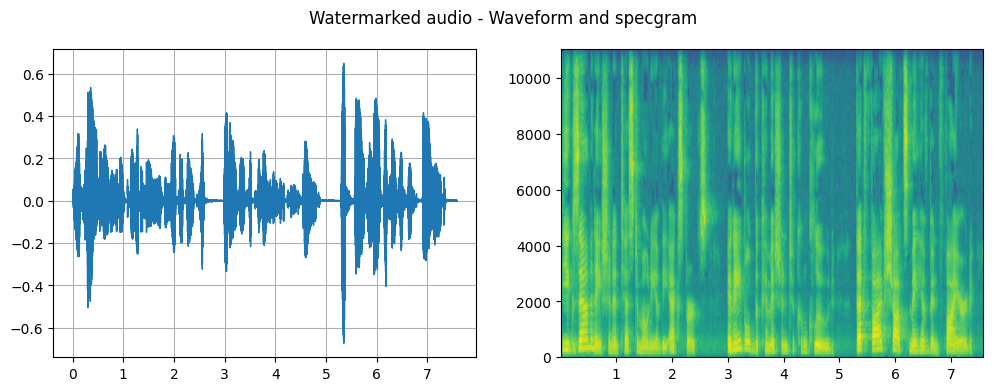

In [73]:
plot_waveform_and_specgram(audio.squeeze(), sr, title="Watermarked audio")

## Adding Watermark

In [74]:
model = AudioSeal.load_generator("audioseal_wm_16bits")

audio = audio.unsqueeze(0).unsqueeze(0)

# watermarked_audio = model(audio, sample_rate=sr, alpha=1)

Or adding our own message

In [75]:
secret_mesage = torch.randint(0, 2, (1, 16), dtype=torch.int32)
print(secret_mesage)
watermarked_audio = model(audio, sample_rate=sr, message=secret_mesage, alpha=1)

tensor([[1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0]], dtype=torch.int32)


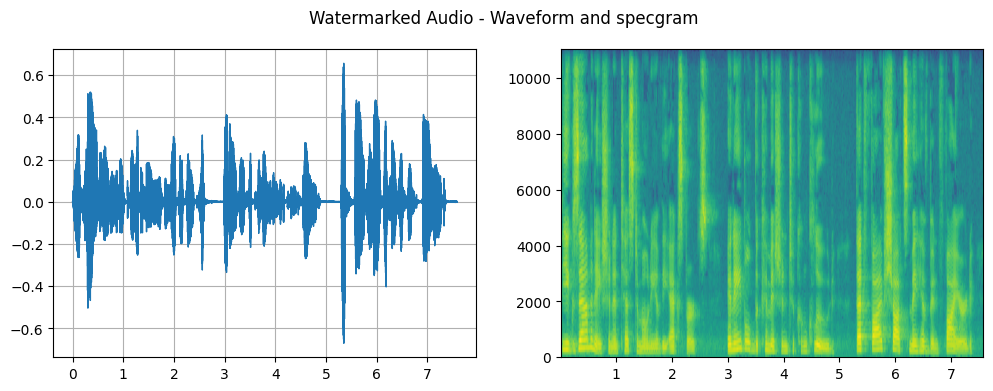

In [76]:
save_audio(watermarked_audio, sr, "watermarked.wav")

plot_waveform_and_specgram(watermarked_audio.squeeze(), sr, title="Watermarked Audio")

## Detector

In [77]:
detector = AudioSeal.load_detector("audioseal_detector_16bits")

result, message = detector.detect_watermark(watermarked_audio, sample_rate=sr, message_threshold=0.5)
print(f"\nThis is likely a watermarked audio. WM probability: {result}")

result2, message2 = detector.detect_watermark(audio, sample_rate=sr, message_threshold=0.5)
print(f"This is likely an unwatermarked audio. WM probability: {result2}")



This is likely a watermarked audio. WM probability: 1.0
This is likely an unwatermarked audio. WM probability: 3.296440627309494e-05


In [79]:
pred_prob, message_prob = detector(watermarked_audio, sample_rate=sr)
print(pred_prob[:, 1, :])
print(message_prob)

tensor([[0.9995, 0.9995, 0.9995,  ..., 0.9979, 0.9979, 0.9979]],
       grad_fn=<SliceBackward0>)
tensor([[0.7818, 0.7590, 0.7649, 0.2624, 0.2317, 0.1949, 0.7967, 0.7369, 0.2725,
         0.2407, 0.2175, 0.2683, 0.8046, 0.1956, 0.2596, 0.2492]],
       grad_fn=<SigmoidBackward0>)


In [30]:
secret_mesage

tensor([[1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0]], dtype=torch.int32)